In [30]:
import numpy as np


In [31]:
loaded_grid = np.load('/Users/joshuapotter/Documents/SEAL/data_ao_libs/example_file_name.npy')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/joshuapotter/Documents/SEAL/data_ao_libs/example_file_name.npy'

In [24]:
import os

filepath = '/Users/joshuapotter/Documents/SEAL/data_ao_libs/example_file_name.npy'

print("Exists:", os.path.exists(filepath))
print("Is file:", os.path.isfile(filepath))
print("Is dir:", os.path.isdir(filepath))

# Try each part of the path
print("SEAL exists?         ", os.path.exists('/Users/joshuapotter/Documents/SEAL'))
print("data_ao_libs is dir? ", os.path.isdir('/Users/joshuapotter/Documents/SEAL/data_ao_libs'))
print("phase_div_sim is dir?", os.path.isdir('/Users/joshuapotter/Documents/SEAL/data_ao_libs/phase_diversity_simulations'))


Exists: False
Is file: False
Is dir: False
SEAL exists?          True
data_ao_libs is dir?  False
phase_div_sim is dir? False


[[0.         1.93363012 2.16913306 1.88283404 2.15364784 1.83190518
  1.7734426  2.02840406 2.33445346 1.89802389]
 [0.         0.         1.93285282 2.01853333 2.00813628 1.8480579
  1.96488347 1.93534218 2.00129248 1.93444261]
 [0.         0.         0.         2.09225653 1.85696698 1.8134775
  1.78232588 2.15699101 1.85449191 1.84723857]
 [0.         0.         0.         0.         1.96112814 2.08002835
  1.9034942  2.01542844 1.97231501 1.94255965]
 [0.         0.         0.         0.         0.         1.98083325
  2.07231644 2.14903478 1.97730183 1.89265908]
 [0.         0.         0.         0.         0.         0.
  2.02620924 2.17769159 1.83961537 2.21356741]
 [0.         0.         0.         0.         0.         0.
  0.         2.00594711 2.00069521 1.84082219]
 [0.         0.         0.         0.         0.         0.
  0.         0.         2.48350634 2.23742576]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.83639242]

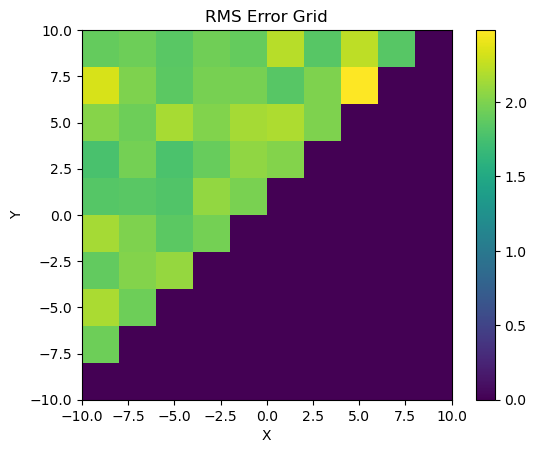

In [39]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
loaded_grid=np.load('/Users/joshuapotter/Documents/SEAL/FDPR_Results/jul16_dean.npy')
print(loaded_grid)
check_rms = loaded_grid
mask = np.triu(check_rms, k=1)
nonzero_indices = np.transpose(np.nonzero(mask))
best_index = min(nonzero_indices, key=lambda idx: check_rms[tuple(idx)])
best_value = check_rms[tuple(best_index)]
# Rebuild defocus distances (same logic you used originally)
dim = check_rms.shape[0]
dean_deltas = dean_bowers_max_list(fringes=11, max_n=dim-1, wavelength=seal_parameters['wavelength_meter'])
best_defocus_pair = (dean_deltas[best_index[0]], dean_deltas[best_index[1]])

print(f"Best physical defocus pair (meters): {best_defocus_pair}")

print(f"Best defocus index pair: {best_index}")
print(f"Minimum RMS error: {best_value:.4f}")
plt.imshow(check_rms.transpose(), extent=(-10,10,-10,10), origin='lower')
plt.colorbar()  #
plt.xlabel('X')
plt.ylabel('Y')
plt.title('RMS Error Grid')
plt.show()

